In [1]:
import geopandas as gpd
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
import numpy as np


from metric_calculation import calculate_classification_metrics, print_classification_report

In [2]:
# calculate the average metrics for all basins across the whole period
hybas_id_list = [
    1020000010, 1020011530, 1020018110, 1020021940, 1020027430, 1020034170, 1020035180, 1020040190,
    2020000010, 2020003440, 2020018240, 2020024230, 2020033490, 2020041390, 2020057170, 2020065840, 2020071190,
    3020000010, 3020003790, 3020005240, 3020008670, 3020009320, 3020024310,
    4020000010, 4020006940, 4020015090, 4020024190, 4020034510, 4020050210, 4020050220, 4020050290, 4020050470,
    5020000010, 5020015660, 5020037270, 5020049720, 5020082270, 
    6020000010, 6020006540, 6020008320, 6020014330, 6020017370, 6020021870, 6020029280,
    7020000010, 7020014250, 7020021430, 7020024600, 7020038340, 7020046750, 7020047840, 7020065090,
    8020000010, 8020008900, 8020010700, 8020020760, 8020022890, 8020032840, 8020044560,
    9020000010
]
start_date = '2001-01-01'
end_date = '2022-01-01'
date_fmt = '%Y-%m-%d'
start_date = datetime.strptime(start_date, date_fmt)
end_date = datetime.strptime(end_date, date_fmt)

prediction_results_pkl_path_pattern = '/WORK/Data/global_lake_area/revision/accuracy_samples/{basin_id}/{basin_id}_{start_date}_{end_date}_samples.pkl'

per_basin_metrics_dict = {}

for hybas_id in hybas_id_list:
    print(f'Calculating metrics for basin {hybas_id}')
    current_date = start_date
    prediction_results_list = []
    while current_date < end_date:
        prediction_results_pkl_path = prediction_results_pkl_path_pattern.format(
            basin_id=hybas_id,
            start_date=current_date.strftime(date_fmt),
            end_date=(current_date + relativedelta(months=1)).strftime(date_fmt)
        )
        prediction_results_gdf = pd.read_pickle(prediction_results_pkl_path)
        prediction_results_gdf = prediction_results_gdf[prediction_results_gdf['gsw'] != 0]
        prediction_results_gdf['gsw'] = prediction_results_gdf['gsw'] - 1
        prediction_results_list.append(prediction_results_gdf)
        current_date += relativedelta(months=1)
    concatenated_prediction_results_gdf = pd.concat(prediction_results_list)
    
    accuracy_metrics = calculate_classification_metrics(
        gdf=concatenated_prediction_results_gdf,
        pred_col='my_water',
        truth_col='gsw'
    )
    per_basin_metrics_dict[hybas_id] = accuracy_metrics

overall_confusion_matrix = np.sum([per_basin_metrics_dict[hybas_id]['Confusion Matrix'] for hybas_id in hybas_id_list], axis=0)
print(overall_confusion_matrix)

Calculating metrics for basin 1020000010
Calculating metrics for basin 1020011530
Calculating metrics for basin 1020018110
Calculating metrics for basin 1020021940
Calculating metrics for basin 1020027430
Calculating metrics for basin 1020034170
Calculating metrics for basin 1020035180
Calculating metrics for basin 1020040190
Calculating metrics for basin 2020000010
Calculating metrics for basin 2020003440
Calculating metrics for basin 2020018240
Calculating metrics for basin 2020024230
Calculating metrics for basin 2020033490
Calculating metrics for basin 2020041390
Calculating metrics for basin 2020057170
Calculating metrics for basin 2020065840
Calculating metrics for basin 2020071190
Calculating metrics for basin 3020000010
Calculating metrics for basin 3020003790
Calculating metrics for basin 3020005240
Calculating metrics for basin 3020008670
Calculating metrics for basin 3020009320
Calculating metrics for basin 3020024310
Calculating metrics for basin 4020000010
Calculating metr

{1020000010: {'Confusion Matrix': array([[608752,  39640],
         [ 21045, 920189]]),
  "User's Accuracy (Precision)": {'Class 0': 0.9665844708691849,
   'Class 1': 0.9587009769448517},
  "Producer's Accuracy (Recall)": {'Class 0': 0.9388641439129416,
   'Class 1': 0.9776410541905626},
  'Overall Accuracy': 0.9618243536529977,
  'F1 Scores': {'Overall': 0.9680783856189932,
   'Class 0': 0.9525226707474405,
   'Class 1': 0.9680783856189932}},
 1020011530: {'Confusion Matrix': array([[3037167,   96675],
         [  89778, 5102352]]),
  "User's Accuracy (Precision)": {'Class 0': 0.9712889097825513,
   'Class 1': 0.9814051744682226},
  "Producer's Accuracy (Recall)": {'Class 0': 0.9691512845893315,
   'Class 1': 0.9827088304799765},
  'Overall Accuracy': 0.9776058579106439,
  'F1 Scores': {'Overall': 0.9820565698314442,
   'Class 0': 0.9702189197620045,
   'Class 1': 0.9820565698314442}},
 1020018110: {'Confusion Matrix': array([[ 613062,   21923],
         [  11645, 1616059]]),
  "User'

In [22]:
hydrobasins_gdf_path = '/WORK/Data/global_lake_area/hydrobasins/merged/hydrobasins_lev02_with_statistics.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)
for hybas_id in hybas_id_list:
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'users_accuracy_water'] = per_basin_metrics_dict[hybas_id]['User\'s Accuracy (Precision)']['Class 1']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'users_accuracy_land'] = per_basin_metrics_dict[hybas_id]['User\'s Accuracy (Precision)']['Class 0']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'producers_accuracy_land'] = per_basin_metrics_dict[hybas_id]['Producer\'s Accuracy (Recall)']['Class 0']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'producers_accuracy_water'] = per_basin_metrics_dict[hybas_id]['Producer\'s Accuracy (Recall)']['Class 1']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'overall_accuracy'] = per_basin_metrics_dict[hybas_id]['Overall Accuracy']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'f1_scores_water'] = per_basin_metrics_dict[hybas_id]['F1 Scores']['Class 1']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'f1_scores_land'] = per_basin_metrics_dict[hybas_id]['F1 Scores']['Class 0']
    hydrobasins_gdf.loc[hydrobasins_gdf['HYBAS_ID'] == hybas_id, 'f1_scores_overall'] = per_basin_metrics_dict[hybas_id]['F1 Scores']['Overall']

hydrobasins_gdf.to_pickle('/WORK/Data/global_lake_area/revision/accuracy_samples/hydrobasins_lev02_with_accuracy_metrics.pkl')

/tmp/ipykernel_64535/2176081121.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['metric_type'] = 1
/WORK/Codes/global_lake_area/revision_codes/accuracy_assessment/../../my_spatial_analyze/data_analyze/correlation_analysis/correlation_plots.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_df[to_group_by_column_name] = pd.cut(to_plot_df[to_group_by_column_name], bins=group_bins, labels=group_labels, ordered=True)


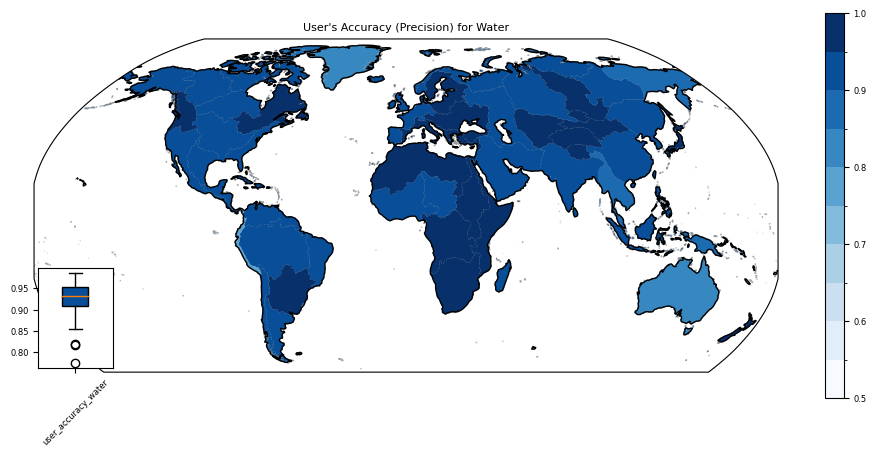

In [28]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

hydrobasins_gdf_path = '/WORK/Data/global_lake_area/revision/accuracy_samples/hydrobasins_lev02_with_accuracy_metrics.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)
# simplify the geometry of the hydrobasins
hydrobasins_gdf.geometry = hydrobasins_gdf.geometry.simplify(tolerance=0.1)

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='users_accuracy_water',
    title='User\'s Accuracy (Precision) for Water',
    use_discrete_color=True,
    discrete_bins=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],
    cmap='Blues',
    edgecolor='none',
    vmin=0.5,
    vmax=1,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='neither'
)

metric_df = hydrobasins_gdf[['HYBAS_ID', 'users_accuracy_water']]
metric_df['metric_type'] = 1

ax_for_box = inset_axes(ax, width="10%", height="30%", loc='lower left')
correlation_plots.box_plot_of_different_groups(
    to_plot_df=metric_df,
    to_plot_column_name='users_accuracy_water',
    to_group_by_column_name='metric_type',
    group_bins=[0, 1],
    group_labels=['user_accuracy_water'],
    show_fliers=True,
    ax=ax_for_box,
    group_colors_box=sm,
    show_plot=False
)

plt.savefig('users_accuracy_water.pdf')

/tmp/ipykernel_64535/1475330816.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['metric_type'] = 1
/WORK/Codes/global_lake_area/revision_codes/accuracy_assessment/../../my_spatial_analyze/data_analyze/correlation_analysis/correlation_plots.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_df[to_group_by_column_name] = pd.cut(to_plot_df[to_group_by_column_name], bins=group_bins, labels=group_labels, ordered=True)


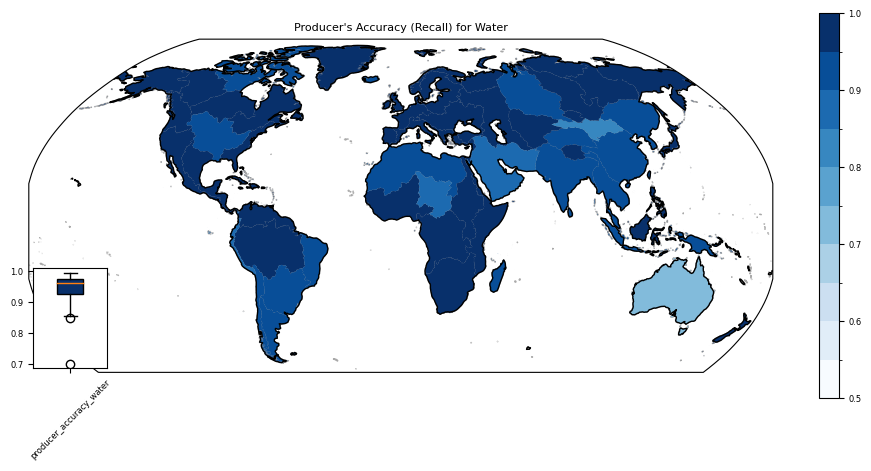

In [29]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

hydrobasins_gdf_path = '/WORK/Data/global_lake_area/revision/accuracy_samples/hydrobasins_lev02_with_accuracy_metrics.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)
# simplify the geometry of the hydrobasins
hydrobasins_gdf.geometry = hydrobasins_gdf.geometry.simplify(tolerance=0.1)

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='producers_accuracy_water',
    title='Producer\'s Accuracy (Recall) for Water',
    use_discrete_color=True,
    discrete_bins=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],
    cmap='Blues',
    edgecolor='none',
    vmin=0.5,
    vmax=1,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='neither'
)

metric_df = hydrobasins_gdf[['HYBAS_ID', 'producers_accuracy_water']]
metric_df['metric_type'] = 1

ax_for_box = inset_axes(ax, width="10%", height="30%", loc='lower left')
correlation_plots.box_plot_of_different_groups(
    to_plot_df=metric_df,
    to_plot_column_name='producers_accuracy_water',
    to_group_by_column_name='metric_type',
    group_bins=[0, 1],
    group_labels=['producer_accuracy_water'],
    show_fliers=True,
    ax=ax_for_box,
    group_colors_box=sm,
    show_plot=False
)

plt.savefig('producers_accuracy_water.pdf')

Initializing pandarallel...
INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


/tmp/ipykernel_14618/593116620.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['metric_type'] = 1
/WORK/Codes/global_lake_area/revision_codes/accuracy_assessment/../../my_spatial_analyze/data_analyze/correlation_analysis/correlation_plots.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_df[to_group_by_column_name] = pd.cut(to_plot_df[to_group_by_column_name], bins=group_bins, labels=group_labels, ordered=True)


count    60.000000
mean      0.937438
std       0.038584
min       0.756759
25%       0.925937
50%       0.937240
75%       0.962032
max       0.989721
Name: f1_scores_water, dtype: float64


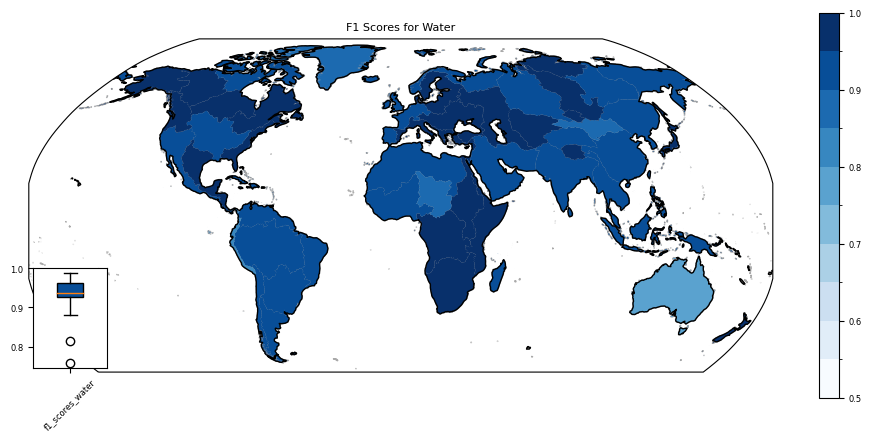

In [1]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

hydrobasins_gdf_path = '/WORK/Data/global_lake_area/revision/accuracy_samples/hydrobasins_lev02_with_accuracy_metrics.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)
# simplify the geometry of the hydrobasins
hydrobasins_gdf.geometry = hydrobasins_gdf.geometry.simplify(tolerance=0.1)

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='f1_scores_water',
    title='F1 Scores for Water',
    use_discrete_color=True,
    discrete_bins=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],
    cmap='Blues',
    edgecolor='none',
    vmin=0.5,
    vmax=1,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='neither'
)

metric_df = hydrobasins_gdf[['HYBAS_ID', 'f1_scores_water']]
metric_df['metric_type'] = 1

ax_for_box = inset_axes(ax, width="10%", height="30%", loc='lower left')
correlation_plots.box_plot_of_different_groups(
    to_plot_df=metric_df,
    to_plot_column_name='f1_scores_water',
    to_group_by_column_name='metric_type',
    group_bins=[0, 1],
    group_labels=['f1_scores_water'],
    show_fliers=True,
    ax=ax_for_box,
    group_colors_box=sm,
    show_plot=False
)
print(metric_df['f1_scores_water'].describe())
plt.savefig('f1_scores_water.pdf')

In [1]:
# draw boxplots for each metric
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd

hydrobasins_gdf_path = '/WORK/Data/global_lake_area/revision/accuracy_samples/hydrobasins_lev02_with_accuracy_metrics.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)

print(hydrobasins_gdf['users_accuracy_water'].describe())
print(hydrobasins_gdf['producers_accuracy_water'].describe())
print(hydrobasins_gdf['f1_scores_water'].describe())

Initializing pandarallel...
INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
count    60.000000
mean      0.928657
std       0.040630
min       0.774179
25%       0.909521
50%       0.933378
75%       0.953977
max       0.987177
Name: users_accuracy_water, dtype: float64
count    60.000000
mean      0.947406
std       0.046095
min       0.702440
25%       0.928402
50%       0.961754
75%       0.976662
max       0.995313
Name: producers_accuracy_water, dtype: float64
count    60.000000
mean      0.937438
std       0.038584
min       0.756759
25%       0.925937
50%       0.937240
75%       0.962032
max       0.989721
Name: f1_scores_water, dtype: float64
